# 2. Introduction to Regression

This notebook provides an in-depth introduction to **Regression**, another fundamental type of supervised machine learning. While classification predicts discrete categories, regression focuses on predicting continuous numerical values.

**Goal:** To model the relationship between a dependent variable (the target) and one or more independent variables (features) to predict a continuous outcome.

**Key Characteristics:**
-   **Continuous Output:** The model's output is a real number within a range.
-   **Supervised Learning:** Models learn from labeled examples where the label is a number.
-   **Relationship Modeling:** Aims to find a function that best describes the relationship between inputs and outputs.

**Common Applications:**
-   **House Price Prediction:** Estimating the market value of a property based on its characteristics.
-   **Stock Price Forecasting:** Predicting future stock prices based on historical data and market indicators.
-   **Demand Forecasting:** Estimating future product demand for inventory management.
-   **Temperature Prediction:** Forecasting daily temperatures based on weather patterns.
-   **Medical Dosage Prediction:** Determining the optimal drug dosage based on patient characteristics.

We will use the **California Housing dataset** to build a regression model that predicts house prices. This dataset is a more modern alternative to the older Boston Housing dataset and is suitable for demonstrating regression concepts.

### Step 1: Import Libraries

First, let's import all the necessary Python libraries for data manipulation, visualization, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6) # Set default figure size

### Step 2: Load and Explore the Dataset

We'll load the California Housing dataset and perform an initial exploration to understand its structure, features, and the target variable (median house value).

In [2]:
# Load the dataset
housing = fetch_california_housing()

# Create a pandas DataFrame
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target

print("--- Dataset Head (First 5 Rows) ---")
print(df.head())

print("\n--- Dataset Information ---")
df.info()

print("\n--- Basic Statistics of Numerical Features ---")
print(df.describe())

--- Dataset Head (First 5 Rows) ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  

### Step 3: Visualize the Data

Visualizing the data helps us understand the distributions of individual features and the relationships between them, especially with the target variable.

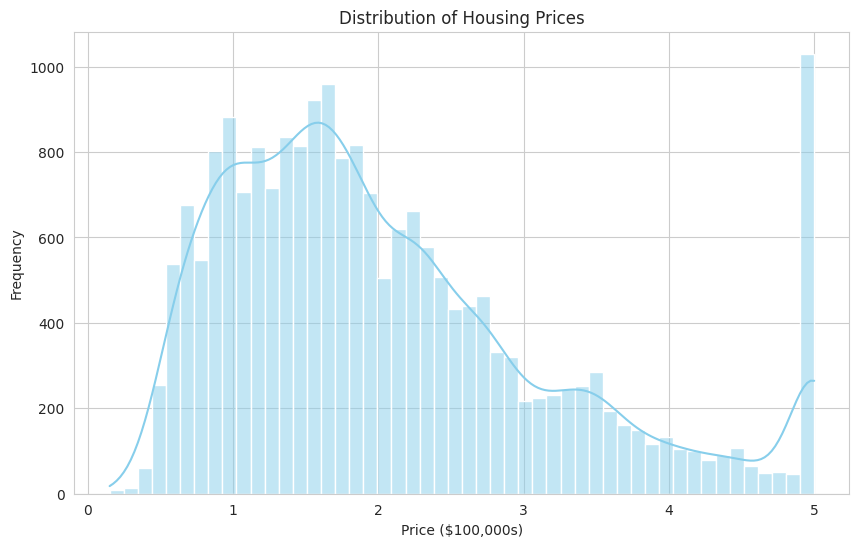

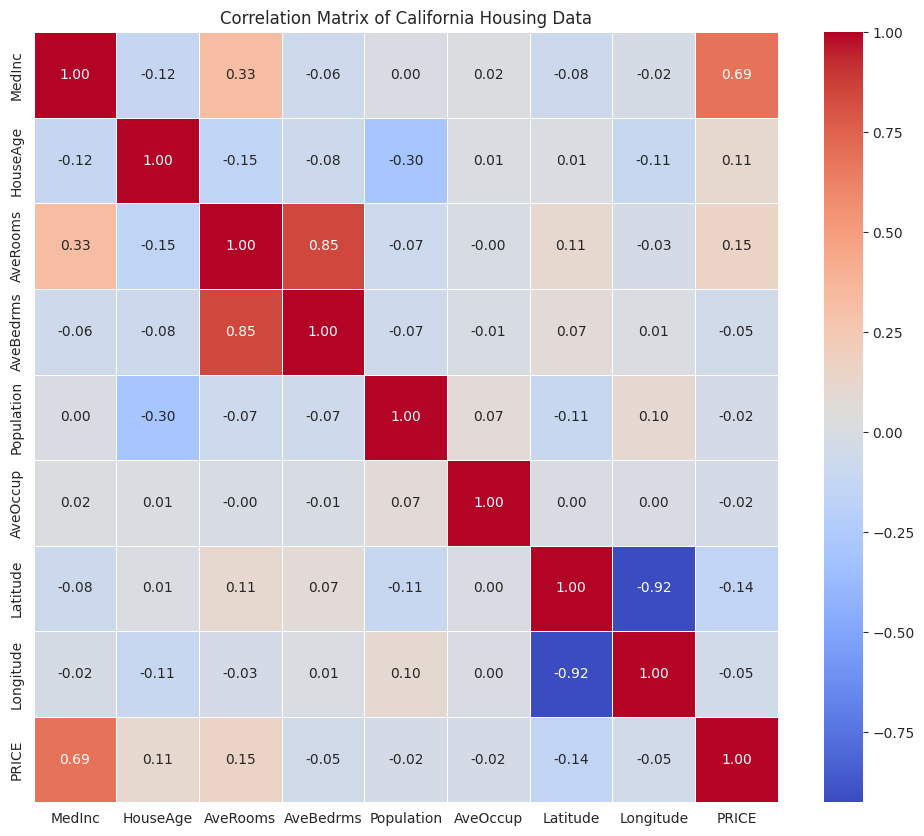

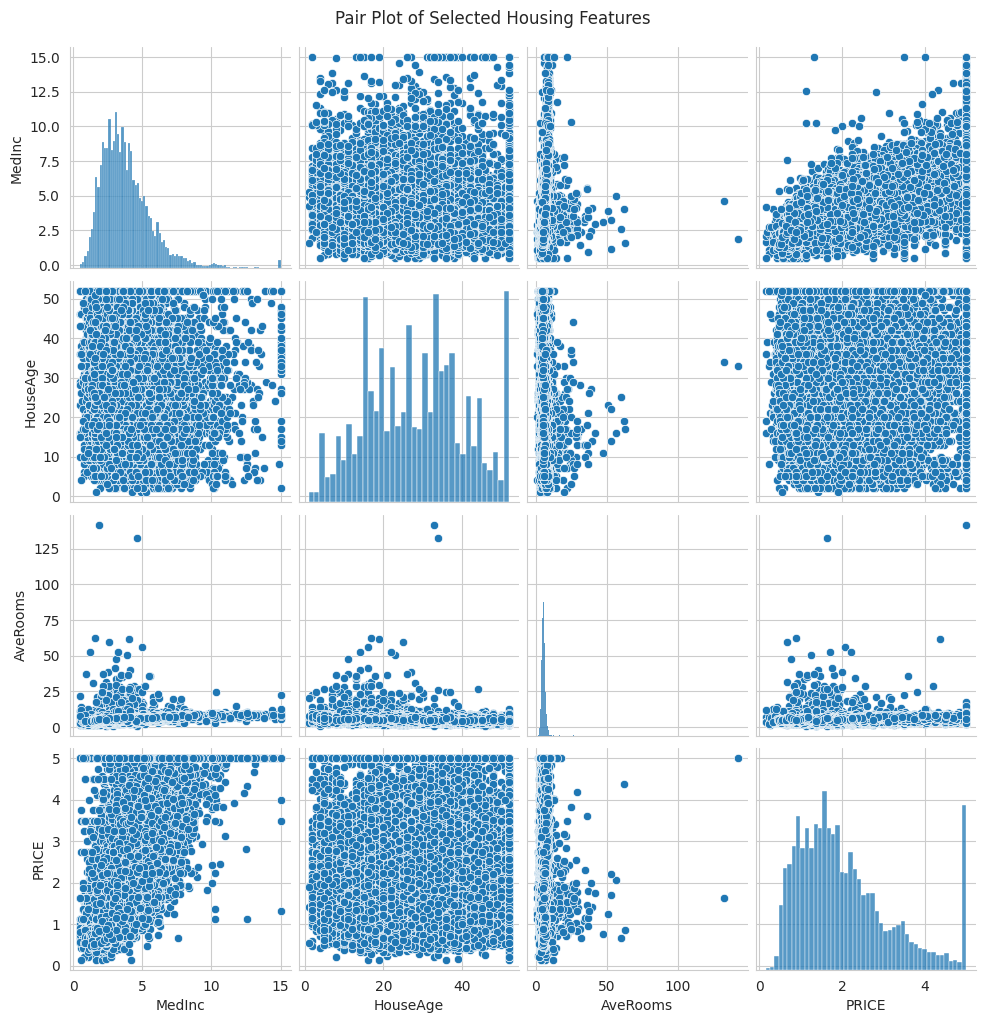

In [3]:
# Distribution of the target variable (PRICE)
sns.histplot(df['PRICE'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Housing Prices')
plt.xlabel('Price ($100,000s)')
plt.ylabel('Frequency')
plt.show()

# Correlation Matrix: Shows linear relationships between all pairs of features
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of California Housing Data')
plt.show()

# Pairplot for a subset of features to visualize relationships
sns.pairplot(df[['MedInc', 'HouseAge', 'AveRooms', 'PRICE']]) # Uncomment to run, can be slow for many features
plt.suptitle('Pair Plot of Selected Housing Features', y=1.02)
plt.show()

**Observation:** The correlation matrix shows how strongly each feature is related to `PRICE`. `MedInc` (Median Income) appears to have the strongest positive correlation with `PRICE`, which makes intuitive sense.

### Step 4: Prepare the Data for Modeling

We need to separate our data into features (`X`) and the target (`y`).

In [4]:
X = df.drop('PRICE', axis=1)
y = df['PRICE']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (20640, 8)
Shape of target (y): (20640,)


### Step 5: Split Data into Training and Testing Sets

As with classification, splitting the data into training and testing sets is essential for evaluating the model's generalization ability.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 16512 samples
Testing set size: 4128 samples


### Step 6: Train a Regression Model (Linear Regression)

We will start with **Linear Regression**, one of the simplest and most widely used regression algorithms. It models the relationship between the independent variables and the dependent variable as a linear equation.

In [11]:
# Create an instance of the LinearRegression model
lr_model = LinearRegression()

# Train the model on the training data
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

# Print the coefficients and intercept
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {lr_model.intercept_:.4f}")

Linear Regression model trained successfully!

Model Coefficients:
  MedInc: 0.4487
  HouseAge: 0.0097
  AveRooms: -0.1233
  AveBedrms: 0.7831
  Population: -0.0000
  AveOccup: -0.0035
  Latitude: -0.4198
  Longitude: -0.4337
Intercept: -37.0233


### Step 7: Evaluate the Model

For regression models, we use different metrics than for classification to quantify prediction accuracy.

In [7]:
# Make predictions on the test data
y_pred_lr = lr_model.predict(X_test)

# Calculate evaluation metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Linear Regression Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"Linear Regression Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Linear Regression R-squared (R2): {r2_lr:.4f}")

Linear Regression Mean Squared Error (MSE): 0.5559
Linear Regression Root Mean Squared Error (RMSE): 0.7456
Linear Regression Mean Absolute Error (MAE): 0.5332
Linear Regression R-squared (R2): 0.5758


**Mean Squared Error (MSE):** The average of the squared differences between the actual and predicted values. Penalizes larger errors more. Lower is better.
**Root Mean Squared Error (RMSE):** The square root of MSE. It's in the same units as the target variable, making it more interpretable. Lower is better.
**Mean Absolute Error (MAE):** The average of the absolute differences between the actual and predicted values. Less sensitive to outliers than MSE. Lower is better.
**R-squared (R2):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). Ranges from 0 to 1, where 1 indicates a perfect fit. Higher is better.

#### Visualizing Predictions vs. Actual Values

A scatter plot of predicted values against actual values can visually represent the model's performance. Ideally, points should cluster around the diagonal line.

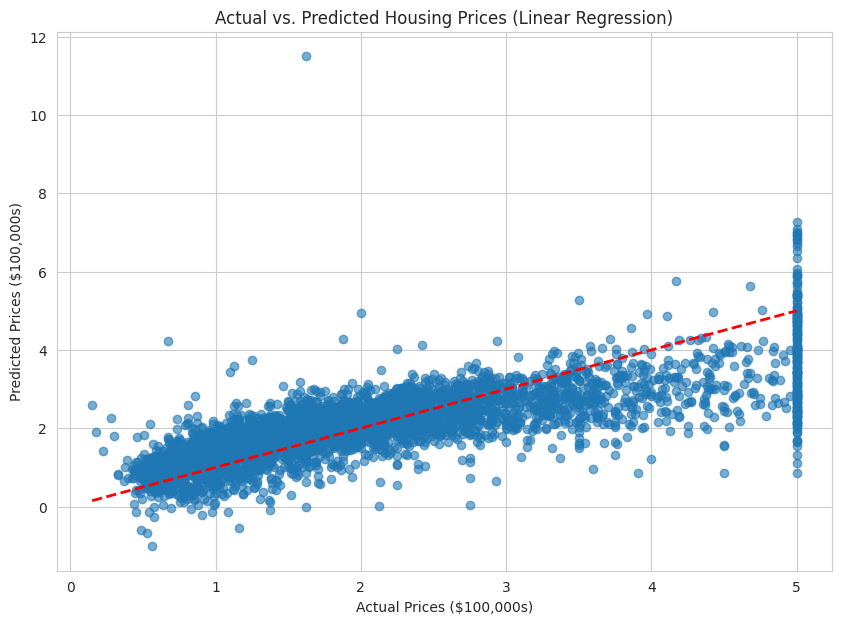

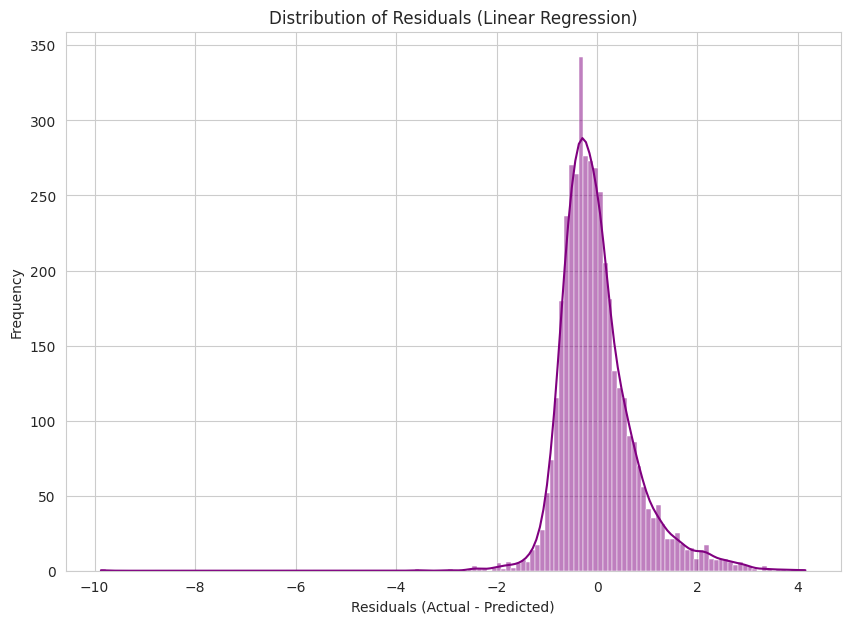

In [8]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual Prices ($100,000s)")
plt.ylabel("Predicted Prices ($100,000s)")
plt.title("Actual vs. Predicted Housing Prices (Linear Regression)")
# Plot a perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.show()

# Plotting residuals
residuals = y_test - y_pred_lr
plt.figure(figsize=(10, 7))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals (Linear Regression)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

### Step 8: Experiment with Other Regression Models

Let's explore two other linear regression variants: **Ridge Regression** and **Lasso Regression**. These are regularized linear models that help prevent overfitting, especially when dealing with many features or multicollinearity.

#### Ridge Regression (L2 Regularization)

Ridge regression adds a penalty equivalent to the square of the magnitude of coefficients. This penalty term shrinks the coefficients towards zero but doesn't set them exactly to zero. It's good for reducing multicollinearity.

In [12]:
# It's often beneficial to scale features for regularized models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0) # alpha is the regularization strength
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression MSE: {mse_ridge:.4f}")
print(f"Ridge Regression R2: {r2_ridge:.4f}")

Ridge Regression MSE: 0.5559
Ridge Regression R2: 0.5758


#### Lasso Regression (L1 Regularization)

Lasso regression adds a penalty equivalent to the absolute value of the magnitude of coefficients. This penalty can shrink some coefficients exactly to zero, effectively performing feature selection. It's useful when you suspect many features are irrelevant.

In [13]:
lasso_model = Lasso(alpha=0.1) # alpha is the regularization strength
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression MSE: {mse_lasso:.4f}")
print(f"Lasso Regression R2: {r2_lasso:.4f}")

Lasso Regression MSE: 0.6796
Lasso Regression R2: 0.4814


### Mini-Challenges / Further Exploration

1.  **Polynomial Features:** Linear regression assumes a linear relationship. Try adding polynomial features to your dataset using `PolynomialFeatures` from `sklearn.preprocessing` before training a `LinearRegression` model. Does this improve the R2 score? (Remember to apply scaling after creating polynomial features if using regularized models). Example:
    ```python
    from sklearn.preprocessing import PolynomialFeatures
    # poly = PolynomialFeatures(degree=2)
    # X_poly = poly.fit_transform(X)
    ```
2.  **Feature Importance (Linear Models):** For linear models, the absolute value of the coefficients can indicate feature importance. Compare the coefficients of the `LinearRegression`, `Ridge`, and `Lasso` models. How do they differ, especially for Lasso?
3.  **Residual Analysis:** Plot the residuals (actual - predicted values) against the predicted values for your best model. What patterns would indicate a good fit? What patterns would suggest problems (e.g., heteroscedasticity)?
4.  **Different Regression Algorithm:** Explore a non-linear regression algorithm like `DecisionTreeRegressor` or `RandomForestRegressor`. How do their performance metrics compare to the linear models?